# Notebook 04 — Optional extensions (advanced)

> **Optional / advanced.** Nothing here is needed for the competition or the
> debrief. It's for groups who finish early and want to explore strategy design
> more deeply. Every section reuses the engine you already have — no new
> Bayesian-optimization code, no debugging BO internals.

The sections are independent — jump to whichever interests you:

1. **Custom scalarization schedule** — change your preference weights round by round.
2. **Explore → exploit schedule** — spend early budget learning, then cash in.
3. **Alternative projection rules** — `nearest` vs `diverse_nearest`.
4. **Information-theoretic acquisitions** — a conceptual look (discussion + one run).

Each section runs a full campaign with `competition.run_campaign` and compares it
to a baseline.

## Setup

In [1]:
import matplotlib.pyplot as plt

from mobo_lab import competition, config, seed
from mobo_lab.acquisitions import format_scalarized_name

seed.set_all_seeds(config.SEED)
N_ROUNDS = config.N_ROUNDS


def auc_and_final(history):
    return history["auc_hv"], history["final_hv"], history["n_nondominated_selected"]


def compare(rows):
    """Print a small comparison table: rows of (label, history)."""
    print(f"{'strategy':<28}{'AUC-HV':>9}{'finalHV':>9}{'nondom':>8}")
    print("-" * 54)
    for label, h in rows:
        a, f, nd = auc_and_final(h)
        print(f"{label:<28}{a:>9.4f}{f:>9.4f}{nd:>8d}")

## 1. Custom scalarization schedule

A *fixed* scalarization commits to one preference for the whole campaign. But your
preference can **change over time**: explore one corner early, then swing the
weights toward an under-explored region. Supply one weight vector per round; the
helper turns each into a `scalarized_w1_w2` card.

In [2]:
weights_by_round = [[0.5, 0.5], [0.8, 0.2], [0.2, 0.8], [0.5, 0.5], [0.8, 0.2], [0.2, 0.8]]
assert len(weights_by_round) == N_ROUNDS

schedule_strategy = [{format_scalarized_name(w): config.BATCH_SIZE} for w in weights_by_round]
print("per-round cards:", [list(p)[0] for p in schedule_strategy])

baseline_strategy = [{"scalarized_0.5_0.5": config.BATCH_SIZE}] * N_ROUNDS

h_schedule = competition.run_campaign(schedule_strategy, "weight_schedule")
h_fixed = competition.run_campaign(baseline_strategy, "fixed_0.5_0.5")

compare([("changing weights", h_schedule), ("fixed 0.5/0.5", h_fixed)])

per-round cards: ['scalarized_0.5_0.5', 'scalarized_0.8_0.2', 'scalarized_0.2_0.8', 'scalarized_0.5_0.5', 'scalarized_0.8_0.2', 'scalarized_0.2_0.8']


strategy                       AUC-HV  finalHV  nondom
------------------------------------------------------
changing weights               0.8276   1.0087       3
fixed 0.5/0.5                  0.8442   1.0087       3


**Teaching point:** because the true front is *concave* (a recessed middle between
two lobes — you'll see this in the Notebook 03 reveal), the weight you pick steers
*which* region you reach. Rotating the preference can broaden coverage of the front
over time; a single fixed weight tends to commit to one part of it. Which wins on
AUC-HV here is seed-dependent and not the point — compare *where* each one's points
land (and how many non-dominated trade-offs each finds) rather than just the score.

## 2. Explore → exploit schedule

Spend early rounds **exploring** (random + ParEGO sample many trade-offs), then
switch to **exploiting** (NEHVI sharpens the front). Compare to playing NEHVI from
the start.

strategy                       AUC-HV  finalHV  nondom
------------------------------------------------------
explore -> exploit             0.8325   1.0356       6
all NEHVI                      0.8588   1.0231       5


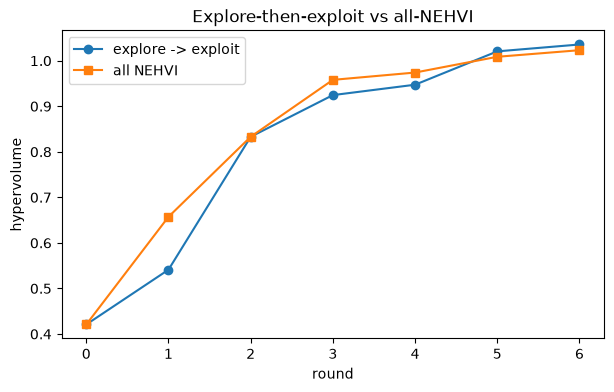

In [3]:
explore_exploit = [
    {"random": 2, "parego": 2},
    {"parego": 4},
    {"nehvi": 2, "parego": 2},
    {"nehvi": 4},
    {"nehvi": 4},
    {"nehvi": 4},
]
assert len(explore_exploit) == N_ROUNDS

all_nehvi = [{"nehvi": config.BATCH_SIZE}] * N_ROUNDS

h_ee = competition.run_campaign(explore_exploit, "explore_then_exploit")
h_nehvi = competition.run_campaign(all_nehvi, "all_nehvi")

compare([("explore -> exploit", h_ee), ("all NEHVI", h_nehvi)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h_ee["hv_history"], marker="o", label="explore -> exploit")
ax.plot(h_nehvi["hv_history"], marker="s", label="all NEHVI")
ax.set_xlabel("round")
ax.set_ylabel("hypervolume")
ax.set_title("Explore-then-exploit vs all-NEHVI")
ax.legend();

**Teaching point:** exploration spends hypervolume *now* to find regions that pay
off *later*. Whether it wins depends on how hidden the good regions are.

## 3. Alternative projection rules

On the **continuous** path, the acquisition optimizer proposes a point in the
design box and we snap it to a real sequence. `nearest` snaps to the closest
unmeasured sequence; `diverse_nearest` also pushes the batch apart, so a clump of
similar proposals fans out. We run the *same* plan both ways (continuous path, so
projection actually matters) and compare.

In [4]:
projection_plan = [{"nehvi": config.BATCH_SIZE}] * N_ROUNDS

h_nearest = competition.run_campaign(
    projection_plan, "proj_nearest", projection_method="nearest", optimize="continuous"
)
h_diverse = competition.run_campaign(
    projection_plan, "proj_diverse", projection_method="diverse_nearest", optimize="continuous"
)

compare([("nearest", h_nearest), ("diverse_nearest", h_diverse)])

strategy                       AUC-HV  finalHV  nondom
------------------------------------------------------
nearest                        0.8388   1.0303       4
diverse_nearest                0.7984   0.9433       4


**Teaching point:** projection decides which designs actually get tested. A
diversity-aware rule can broaden coverage of the front when the optimizer keeps
proposing similar points. (Stretch ideas: cluster-aware projection, or a
similarity penalty that discourages near-duplicate sequences.)

## 4. Information-theoretic acquisitions (conceptual)

The core lab scores candidates by *expected hypervolume improvement*. An
alternative family scores by **information gain** — pick the antibody whose
measurement would most reduce the model's uncertainty about the Pareto front
(e.g. PES / MES / JES). These are powerful but heavier to set up and tune, so they
are **beyond the core lab**.

Our `uncertainty` card is a lightweight stand-in for the *spirit* of these
methods: it spends the batch where the model is least sure, ignoring the mean.
Here is a single round of it versus NEHVI, just to see the contrast — not
something to debug.

In [5]:
uncertainty_plan = [{"uncertainty": config.BATCH_SIZE}] + [{"nehvi": config.BATCH_SIZE}] * (N_ROUNDS - 1)
h_unc = competition.run_campaign(uncertainty_plan, "uncertainty_first")
compare([("uncertainty then NEHVI", h_unc), ("all NEHVI", h_nehvi)])

strategy                       AUC-HV  finalHV  nondom
------------------------------------------------------
uncertainty then NEHVI         0.9625   1.0356       7
all NEHVI                      0.8588   1.0231       5


**Teaching point:** pure uncertainty-seeking explores aggressively but ignores
whether a region is actually *good*; real information-theoretic methods target
uncertainty *about the Pareto front specifically*, which is why they can be worth
the extra machinery.

---
That's the menu. The big idea across all four: the closed loop stays the same —
you are only changing *how each batch is chosen*.